# Importaciones Necesarias:

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lectura de los datos

In [107]:
datos = pd.read_csv('student_dropout_dataset_v3.csv')
drop_cols = ["Student_ID", "Dropout"]

X = datos.drop(columns=drop_cols)
y = datos['Dropout']

X['Semester'] = X['Semester'].str[-1].astype(int)

# Resumen de los datos

In [108]:
resumenEntrada = X.describe()
resumenSalida = y.describe()
print(resumenEntrada)
print(resumenSalida)

               Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  10000.00000    9500.000000          9500.000000      10000.00000   
mean      21.02606   38377.247474             4.014592         81.73683   
std        2.13981   20496.232179             1.295450          8.22093   
min       17.00000   25000.000000             0.500000         38.20000   
25%       19.50000   25000.000000             3.160000         76.40000   
50%       21.00000   29740.500000             4.000000         81.80000   
75%       22.50000   44520.000000             4.870000         87.30000   
max       29.60000  316601.000000             8.980000        100.00000   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index           GPA  \
count           10000.000000          10000.00000   9500.000000  10000.000000   
mean                1.799700             30.17926      5.507147      2.308440   
std                 1.344307             11.91887      1.765951      1.061717   


# Gráficas para mostrar datos:

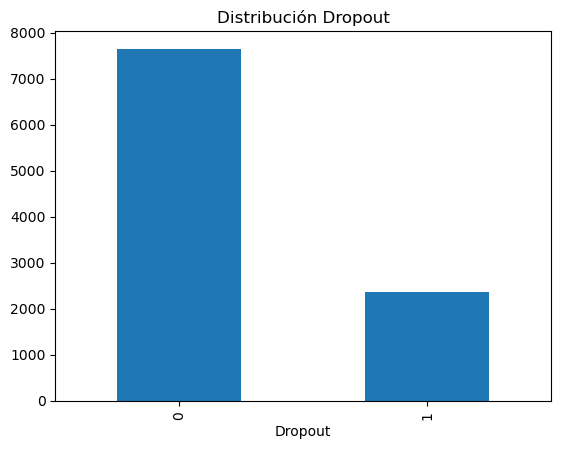

In [109]:
# Gráfica que muestra la distribución de dropout

y.value_counts().plot(kind="bar")
plt.title("Distribución Dropout")
plt.show()

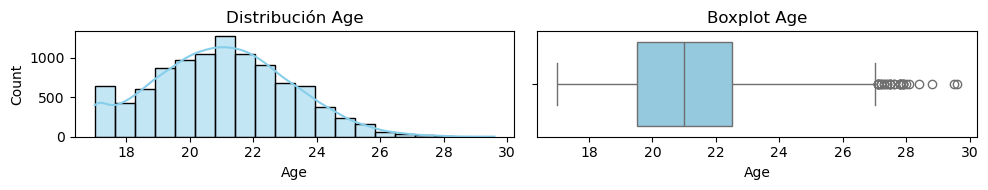

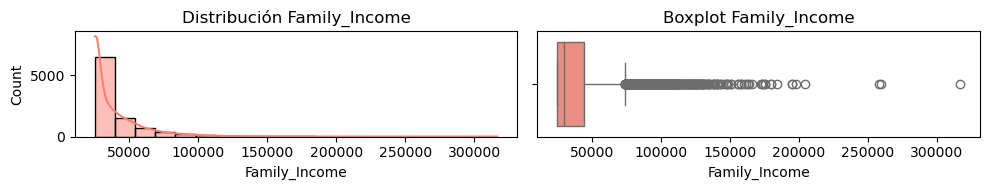

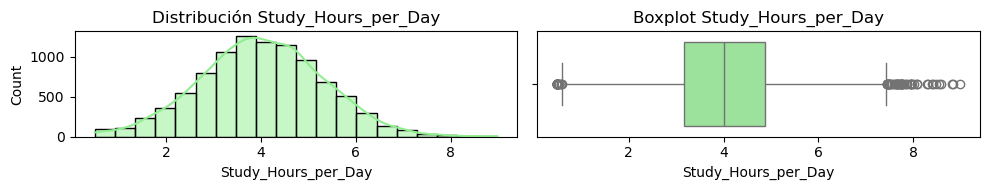

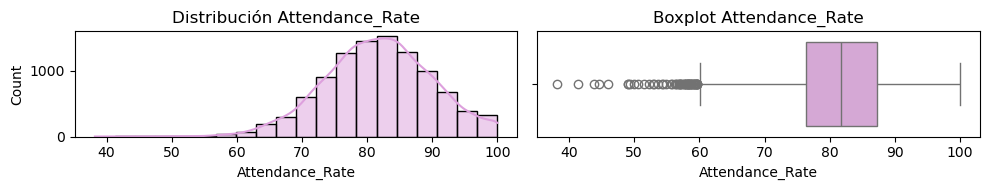

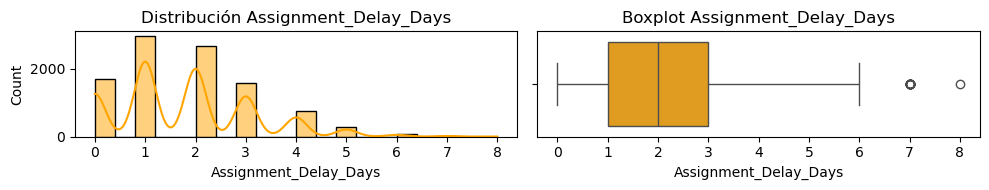

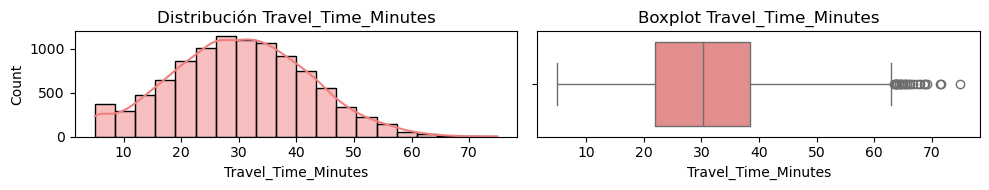

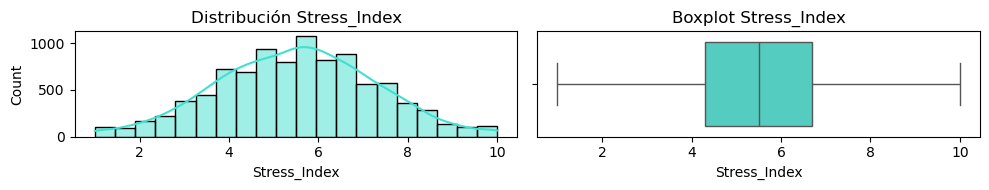

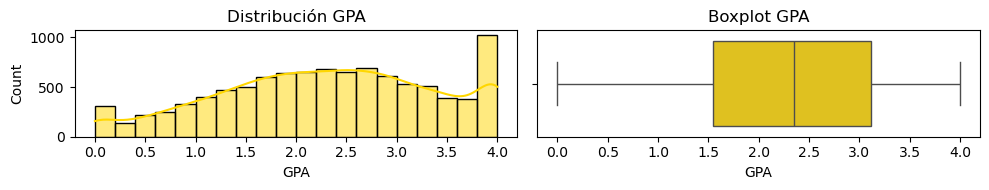

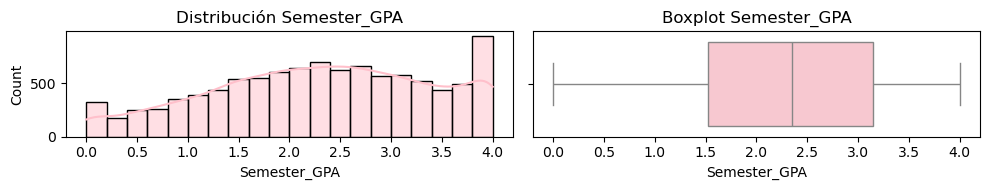

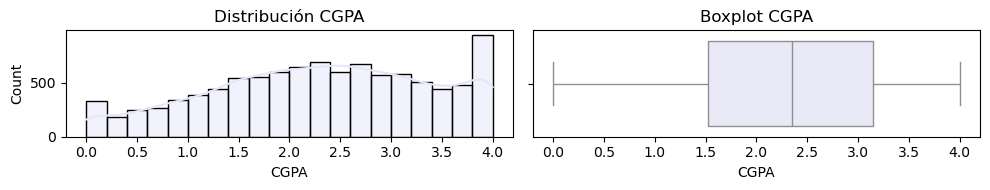

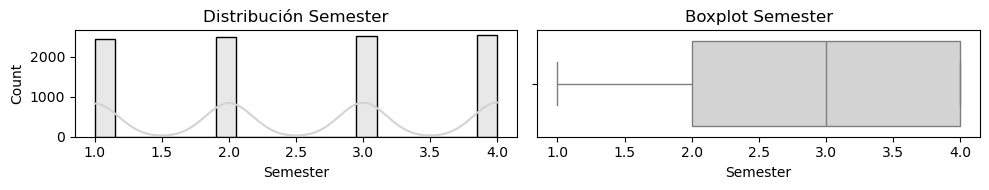

In [110]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

colors = ["skyblue", "salmon", "lightgreen", "plum", "orange", 
          "lightcoral", "turquoise", "gold", "pink", "lavender", "lightgray"]

for col, color in zip(num_cols, colors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    sns.histplot(data=X, x=col, bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"Distribución {col}")
    
    sns.boxplot(data=X, x=col, color=color, ax=axes[1])
    axes[1].set_title(f"Boxplot {col}")
    
    plt.tight_layout()
    plt.show()

# División de datos en conjuntos de entrenamiento , validación y test.

In [111]:
from sklearn.model_selection import train_test_split

# test es el 10% de los ejemplos, entranmiento es 80% y validación el resto.
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size = 0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size = 0.20, stratify=y_resto, random_state=42)


# Detección y tratamiento de outliers:

Detección de outliers con IQR y mediana

In [112]:
# Importamos la clase TransformerMixin
from sklearn.base import TransformerMixin

# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.median = X[self.columns].median()

        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        Q1 = self.stats.loc['25%']   
        Q3 = self.stats.loc['75%']
        IQRs = Q3 - Q1
        limiteInf = Q1 - self.k * IQRs
        limiteSup = Q3 + self.k * IQRs  
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Detección de outliers con media y desviación (mediana)

In [113]:
# Importamos la clase TransformerMixin
from sklearn.base import TransformerMixin

# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_MeanStd(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.media = X[self.columns].mean()
        self.desviacion = X[self.columns].std()
        self.median = X[self.columns].median()
        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        
        limiteInf = self.media - self.k * self.desviacion
        limiteSup = self.media + self.k * self.desviacion 
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Mismos Detectores de Outliers pero reemplazando por extremos:

In [114]:
from sklearn.base import TransformerMixin
import pandas as pd

class OutlierDetecion_treatment_IQR_Extremos(TransformerMixin):

    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
        
        # Calculamos estadísticos solo de las variables numéricas
        self.stats = X[self.columns].describe(percentiles=[0.25, 0.75])
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        Xaux = X.copy()

        IQRs      = self.stats.loc["75%", :] - self.stats.loc["25%", :]
        limiteInf = self.stats.loc["25%", :] - self.k * IQRs
        limiteSup = self.stats.loc["75%", :] + self.k * IQRs

        # Iteramos SOLO por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]

        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}
    
    from sklearn.base import TransformerMixin
import pandas as pd

class OutlierDetecion_treatment_MeanStd_Extremos(TransformerMixin):
    
    # Añadimos el parámetro columns al constructor
    def __init__(self, k=2, columns=None):
        self.k = k
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
            
        # Calculamos media y desviación SOLO de las numéricas
        self.mean_ = X[self.columns].mean()
        self.std_  = X[self.columns].std()
        return self
    
    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        
        limiteInf = self.mean_ - self.k * self.std_
        limiteSup = self.mean_ + self.k * self.std_
        
        # Iteramos SOLO por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]
        
        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

In [135]:
# Aqui de momento elegimos a mado el tipo de tratamiento de outlier, IQR, MeanStd o 
out_IQR = OutlierDetecion_treatment_IQR(k=3)
out_IQR.fit(X_train)

# Test y Train sin Outliers

X_train_IQR = out_IQR.transform(X_train)
X_test_IQR = out_IQR.transform(X_test)

print(X_train_IQR.shape)
print(X_train.shape)

(7200, 17)
(7200, 17)


# Imputar valores perdidos en categoricas y numéricas:

In [144]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.impute import IterativeImputer

columnas_numericas = list(X_train_IQR.select_dtypes(include="number").columns)
columnas_categoricas = list(X_train_IQR.select_dtypes(include="object").columns)

print(columnas_numericas)
print(columnas_categoricas)

# Aqui he utilizado un tipo de imputacion ( luego cuando tengamos el knn hecho se prueban diferentes para ver cual va mejor etc etc...)

imputerr = ColumnTransformer(transformers=[("imp_numericas", SimpleImputer(strategy="mean"), columnas_numericas), 
                                            ("imp_categoricas", SimpleImputer(strategy="most_frequent"), columnas_categoricas)], remainder="passthrough")

imputer_knn = ColumnTransformer(transformers=[("imp_numericas", KNNImputer(n_neighbors=5, weights="uniform"), 
                                               columnas_numericas), ("imp_categoricas", SimpleImputer(strategy="most_frequent"), columnas_categoricas)], 
                                                   remainder="passthrough"
)
imputer = ColumnTransformer(transformers=[("imp_numericas", IterativeImputer(max_iter=10, random_state=42), 
                                                     columnas_numericas), ("imp_categoricas", SimpleImputer(strategy="most_frequent"), columnas_categoricas)], 
                                                        remainder="passthrough"
)
imputer.fit(X_train_IQR)
X_train_imputado = imputer.transform(X_train_IQR)
X_test_imputado = imputer.transform(X_test_IQR)
cols_orden = columnas_numericas + columnas_categoricas
X_train_imputado = pd.DataFrame(X_train_imputado, columns=cols_orden, index=X_train_IQR.index)
X_test_imputado  = pd.DataFrame(X_test_imputado,  columns=cols_orden, index=X_test_IQR.index)

['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester']
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Department', 'Parental_Education']


# Pasar valores categoricos a numéricos:

In [145]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# De momento solo pongo un tipo de encoder para probar!

encoder = ColumnTransformer(transformers=[("ohe", OneHotEncoder(),columnas_categoricas),],remainder="passthrough")
encoder.fit(X_train_imputado)
X_train_enc = encoder.transform(X_train_imputado)
X_test_enc  = encoder.transform(X_test_imputado)
print(X_train_enc)


[[1.0 0.0 1.0 ... 1.96 1.97 2.0]
 [1.0 0.0 0.0 ... 0.98 0.98 1.0]
 [0.0 1.0 0.0 ... 2.56 2.56 1.0]
 ...
 [0.0 1.0 0.0 ... 3.58 3.66 4.0]
 [0.0 1.0 0.0 ... 4.0 4.0 4.0]
 [1.0 0.0 0.0 ... 3.52 3.52 2.0]]


## Métricas de rendimiento

In [146]:
X_val_IQR = out_IQR.transform(X_val)
#Imputamos valores perdidos
X_val_imputado = imputer.transform(X_val_IQR)
X_val_imputado = pd.DataFrame(X_val_imputado, columns=cols_orden, index=X_val_IQR.index)
#Codificamos valores categoricas
X_val_enc = encoder.transform(X_val_imputado)

X_train_final =  X_train_enc
X_val_final = X_val_enc
X_test_final = X_test_enc

print(X_train_final.shape, X_val_final.shape, X_test_final.shape)

(7200, 28) (1800, 28) (1000, 28)


In [147]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train_final, y_train)

KNeighborsClassifier()

In [148]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report

y_val_pred = modelo.predict(X_val_final)
matriz_confusion = confusion_matrix(y_val, y_val_pred)

print("Matriz de confusión:")
print(matriz_confusion)
print()
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, pos_label=1))
print("Recall:", recall_score(y_val, y_val_pred, pos_label=1))
print("F1:", f1_score(y_val, y_val_pred, pos_label=1))
print()
print(classification_report(y_val, y_val_pred))

Matriz de confusión:
[[1261  115]
 [ 358   66]]

Accuracy: 0.7372222222222222
Balanced accuracy: 0.5360423979815708
Precision: 0.36464088397790057
Recall: 0.15566037735849056
F1: 0.21818181818181817

              precision    recall  f1-score   support

           0       0.78      0.92      0.84      1376
           1       0.36      0.16      0.22       424

    accuracy                           0.74      1800
   macro avg       0.57      0.54      0.53      1800
weighted avg       0.68      0.74      0.70      1800



In [149]:
from sklearn.metrics import roc_curve,roc_auc_score,precision_recall_curve,auc

y_val_proba = modelo.predict_proba(X_val_final)[:, 1]

fpr, tpr, umbrales_roc = roc_curve(y_val, y_val_proba, pos_label=1)
roc_auc = roc_auc_score(y_val, y_val_proba)

precision_curve, recall_curve, umbrales_pr = precision_recall_curve(y_val, y_val_proba, pos_label=1)
pr_auc = auc(recall_curve, precision_curve)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.584938226744186
PR-AUC: 0.30596153995078285


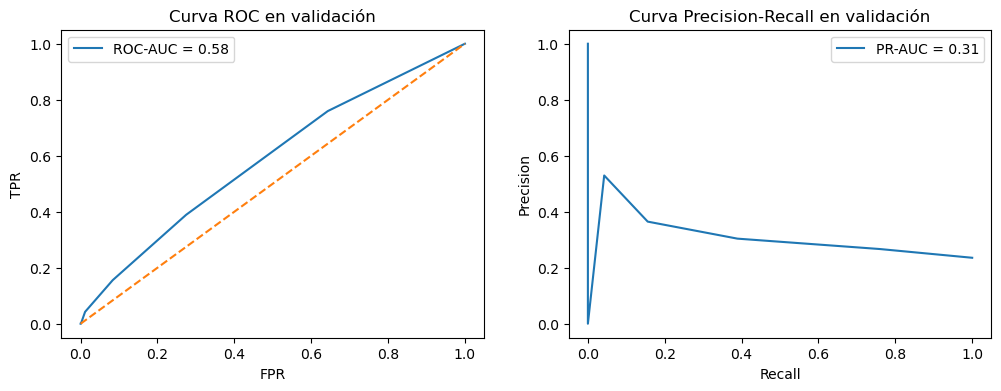

In [150]:
fig,ax = plt.subplots(1,2,figsize = (12,4))

ax[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].set_title("Curva ROC en validación")
ax[0].legend()

ax[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.2f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall en validación")
ax[1].legend()
plt.show()

In [151]:
umbrales = np.arange(0.10, 1.00, 0.05)

resultados_umbral = []

for umbral in umbrales:
    y_val_umbral = (y_val_proba >= umbral).astype(int)
    acc = accuracy_score(y_val, y_val_umbral)
    bal_acc = balanced_accuracy_score(y_val, y_val_umbral)
    prec = precision_score(y_val, y_val_umbral, pos_label=1)
    rec = recall_score(y_val, y_val_umbral, pos_label=1)
    f1 = f1_score(y_val, y_val_umbral, pos_label=1)
    resultados_umbral.append([umbral, acc, bal_acc, prec, rec, f1])

tabla_umbral = pd.DataFrame(resultados_umbral, columns=["umbral", "accuracy", "balanced_accuracy", "precision", "recall", "f1"])
tabla_umbral

,umbral,accuracy,balanced_accuracy,precision,recall,f1
0,0.10,0.451667,0.558133,0.266777,0.759434,0.394850
1,0.15,0.451667,0.558133,0.266777,0.759434,0.394850
2,0.20,0.646111,0.557221,0.303867,0.389151,0.341262
3,0.25,0.646111,0.557221,0.303867,0.389151,0.341262
4,0.30,0.646111,0.557221,0.303867,0.389151,0.341262
5,0.35,0.646111,0.557221,0.303867,0.389151,0.341262
6,0.40,0.737222,0.536042,0.364641,0.155660,0.218182
7,0.45,0.737222,0.536042,0.364641,0.155660,0.218182
8,0.50,0.737222,0.536042,0.364641,0.155660,0.218182
9,0.55,0.737222,0.536042,0.364641,0.155660,0.218182


In [152]:
mejor_f1 = tabla_umbral.loc[tabla_umbral["f1"].idxmax()]
umbral_optimo = mejor_f1["umbral"]

print("Mejor fila según F1:")
print(mejor_f1)
print()
print("Umbral óptimo:", umbral_optimo)

Mejor fila según F1:
umbral               0.100000
accuracy             0.451667
balanced_accuracy    0.558133
precision            0.266777
recall               0.759434
f1                   0.394850
Name: 0, dtype: float64

Umbral óptimo: 0.1


In [153]:
y_test_proba = modelo.predict_proba(X_test_final)[:,1]
y_test_pred = (y_test_proba >= umbral_optimo).astype(int)

matriz_confusion_test = confusion_matrix(y_test,y_test_pred)

print("Matriz de confusión en test:")
print(matriz_confusion_test)
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)
pr_auc_test = auc(recall_test, precision_test)
print("PR-AUC:", pr_auc_test)

Matriz de confusión en test:
[[244 521]
 [ 66 169]]

Accuracy: 0.413
Balanced accuracy: 0.5190515922681129
Precision: 0.24492753623188407
Recall: 0.7191489361702128
F1: 0.3654054054054054
ROC-AUC: 0.5504491725768321
PR-AUC: 0.29825888697093295


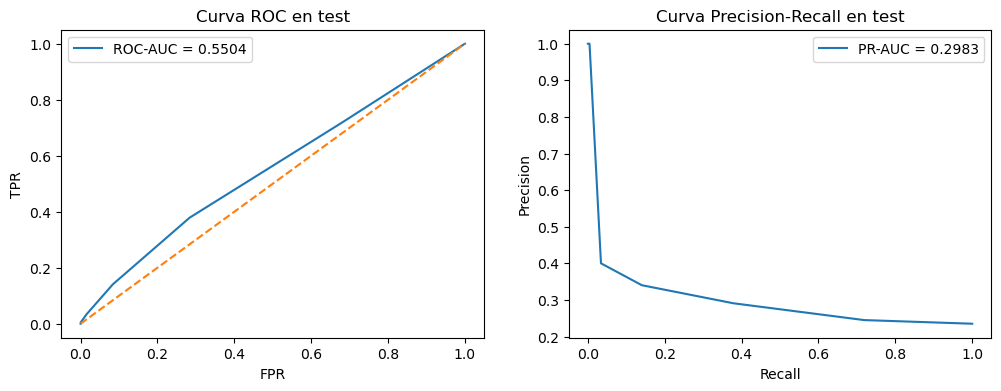

In [154]:
fig,ax = plt.subplots(1,2,figsize = (12,4))

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba, pos_label=1)

ax[0].plot(fpr_test, tpr_test, label=f"ROC-AUC = {roc_auc_score(y_test, y_test_proba):.4f}")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].set_title("Curva ROC en test")
ax[0].legend()

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)

ax[1].plot(recall_test, precision_test, label=f"PR-AUC = {auc(recall_test, precision_test):.4f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall en test")
ax[1].legend()
plt.show()